In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage


In [5]:
data = pd.read_csv('gaia_stars_with_phases.csv')
print(f"Dataset contains {len(data)} stars")
print("\nAvailable columns:", data.columns.tolist())

Dataset contains 70118 stars

Available columns: ['ra', 'dec', 'parallax', 'parallax_error', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'bp_rp', 'radial_velocity', 'ruwe', 'teff_gspphot', 'phot_variable_flag', 'distance_pc', 'abs_mag', 'phase', 'cluster']


In [6]:
# Prepare feature matrix
features = data[['bp_rp', 'abs_mag', 'teff_gspphot']].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

1. Optimal Cluster count(Silhouette)

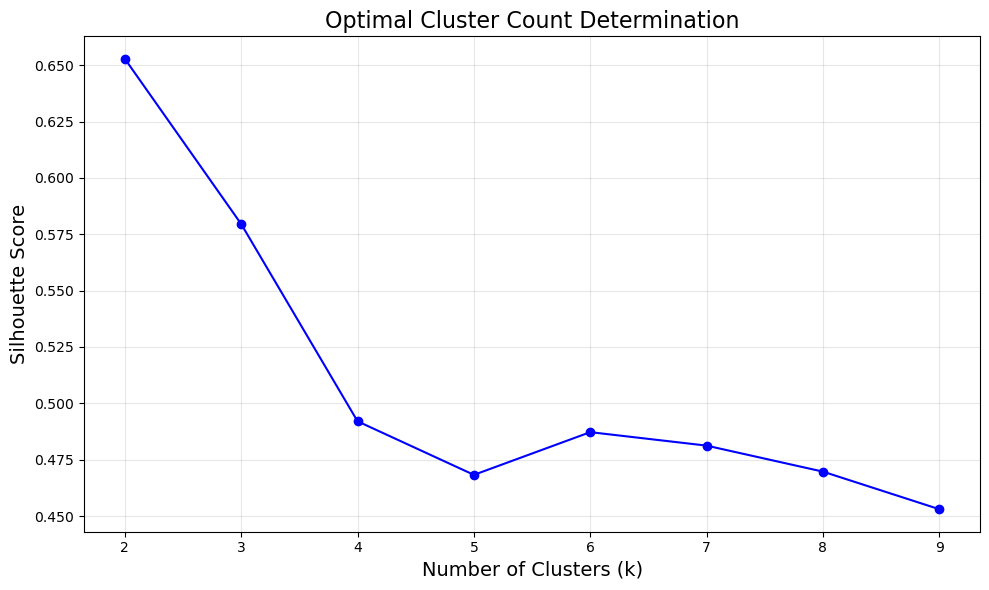

Optimal cluster count: 2


In [7]:
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'bo-')
plt.xlabel('Number of Clusters (k)', fontsize=14)
plt.ylabel('Silhouette Score', fontsize=14)
plt.title('Optimal Cluster Count Determination', fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal cluster count: {k_range[np.argmax(silhouette_scores)]}")

Guassian Mixture Model(GMM)

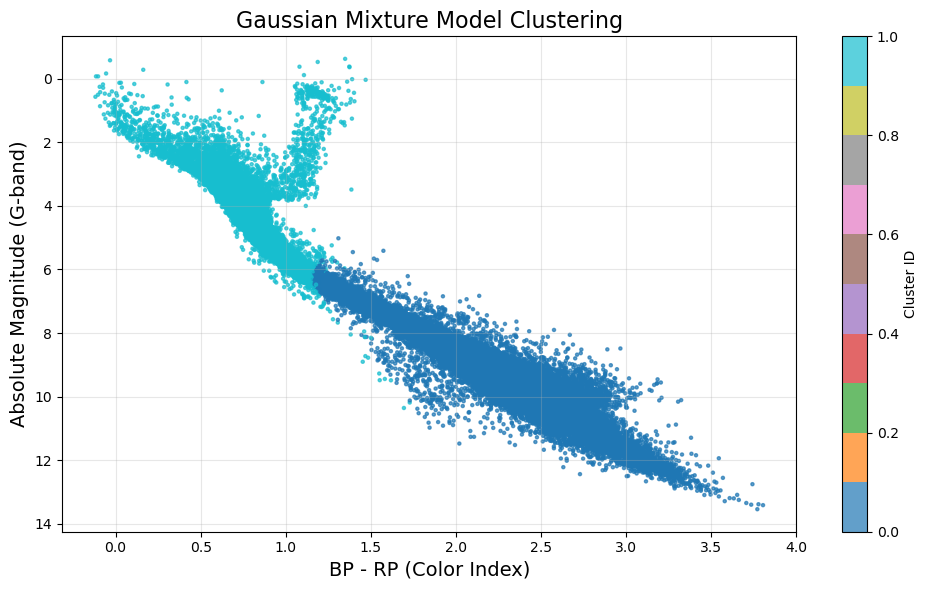


GMM Cluster Characteristics:


,gmm_cluster,bp_rp,abs_mag,teff_gspphot,phase
0,0,2.114170,8.864128,3819.312475,Main Sequence
1,1,0.843892,4.578499,5707.981478,Main Sequence


In [8]:
n_components = k_range[np.argmax(silhouette_scores)]
gmm = GaussianMixture(n_components=n_components, random_state=42)
data['gmm_cluster'] = gmm.fit_predict(X_scaled)

# Visualize clusters
plt.figure(figsize=(10, 6))
sc = plt.scatter(
    data['bp_rp'], 
    data['abs_mag'], 
    c=data['gmm_cluster'], 
    s=5, 
    alpha=0.7,
    cmap='tab10'
)
plt.gca().invert_yaxis()
plt.xlabel('BP - RP (Color Index)', fontsize=14)
plt.ylabel('Absolute Magnitude (G-band)', fontsize=14)
plt.title('Gaussian Mixture Model Clustering', fontsize=16)
plt.colorbar(sc, label='Cluster ID')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Analyze cluster properties
gmm_cluster_stats = data.groupby('gmm_cluster').agg({
    'bp_rp': 'mean',
    'abs_mag': 'mean',
    'teff_gspphot': 'mean',
    'phase': lambda x: x.value_counts().index[0]  # Most common phase
}).reset_index()
print("\nGMM Cluster Characteristics:")
display(gmm_cluster_stats)

--- 
# ☢️☣️ KERNEL CRASH⛔️

Hierarchical Clusterring

In [1]:
# Compute linkage matrix
Z = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode='lastp', p=20)
plt.xlabel('Sample Index or Cluster Size', fontsize=14)
plt.ylabel('Distance', fontsize=14)
plt.title('Hierarchical Clustering Dendrogram', fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'linkage' is not defined

In [ ]:
# Fit Agglomerative Clustering
agg_cluster = AgglomerativeClustering(n_clusters=n_components, linkage='ward')
data['hierarchical_cluster'] = agg_cluster.fit_predict(X_scaled)

# Visualize clusters
plt.figure(figsize=(10, 6))
sc = plt.scatter(
    data['bp_rp'], 
    data['abs_mag'], 
    c=data['hierarchical_cluster'], 
    s=5, 
    alpha=0.7,
    cmap='tab10'
)
plt.gca().invert_yaxis()
plt.xlabel('BP - RP (Color Index)', fontsize=14)
plt.ylabel('Absolute Magnitude (G-band)', fontsize=14)
plt.title('Hierarchical Clustering', fontsize=16)
plt.colorbar(sc, label='Cluster ID')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

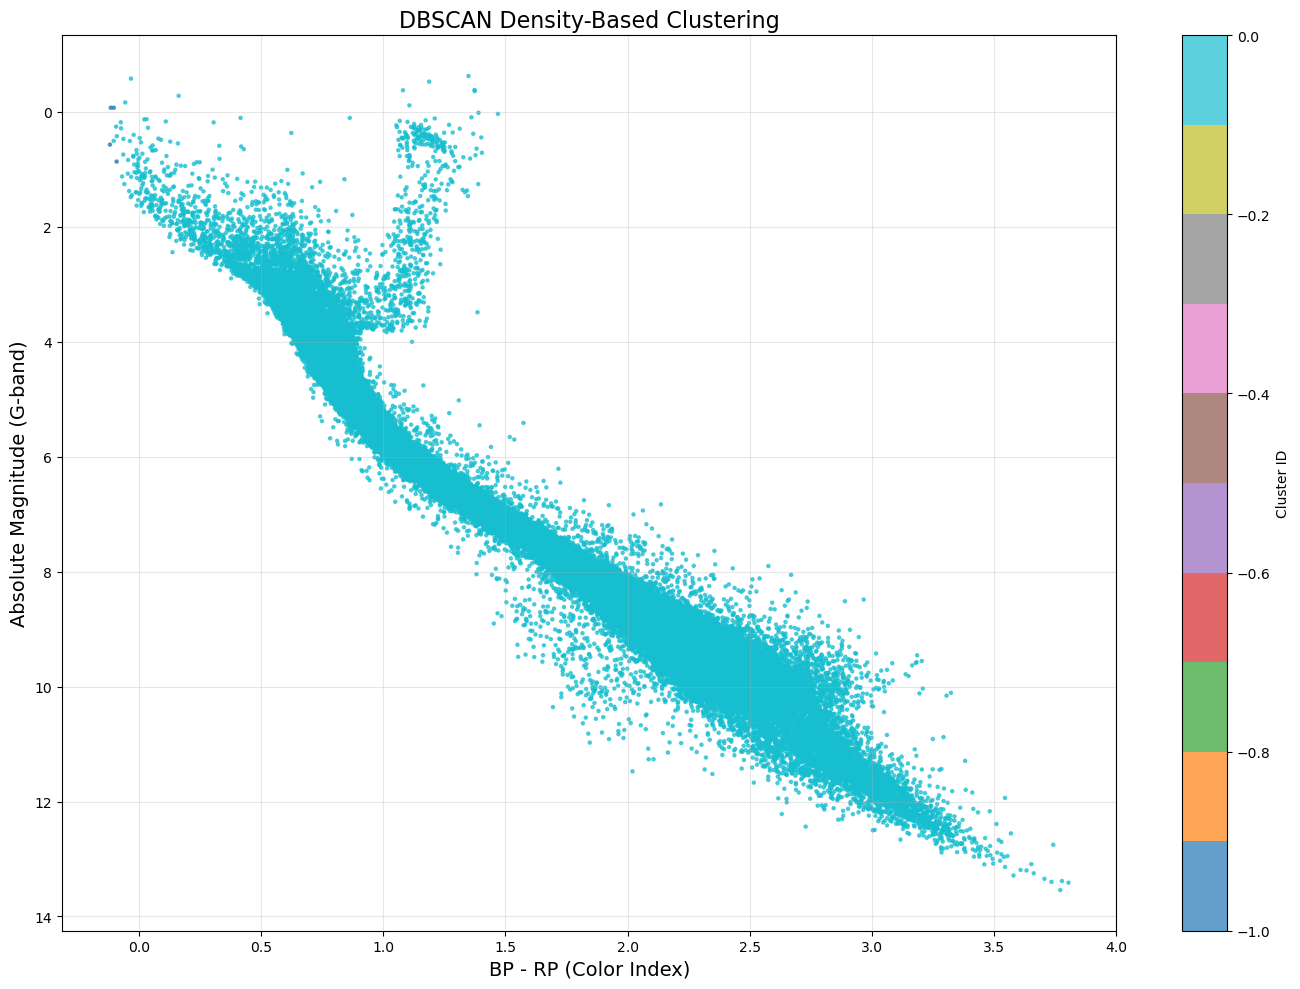


DBSCAN Cluster Distribution:
dbscan_cluster
 0    70114
-1        4
Name: count, dtype: int64


In [9]:
dbscan = DBSCAN(eps=0.5, min_samples=10)
data['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

# Visualize clusters
plt.figure(figsize=(14, 10))
sc = plt.scatter(
    data['bp_rp'], 
    data['abs_mag'], 
    c=data['dbscan_cluster'], 
    s=5, 
    alpha=0.7,
    cmap='tab10'
)
plt.gca().invert_yaxis()
plt.xlabel('BP - RP (Color Index)', fontsize=14)
plt.ylabel('Absolute Magnitude (G-band)', fontsize=14)
plt.title('DBSCAN Density-Based Clustering', fontsize=16)
plt.colorbar(sc, label='Cluster ID')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Analyze cluster distribution
dbscan_counts = data['dbscan_cluster'].value_counts()
print("\nDBSCAN Cluster Distribution:")
print(dbscan_counts)

In [ ]:
# Define clustering methods
methods = ['phase', 'cluster', 'gmm_cluster', 'dbscan_cluster']

# Create a new comparison dataframe with only existing columns
comparison = data[methods + ['bp_rp', 'abs_mag']].copy()

phase_mapping = {
    0: 'Main Sequence',
    1: 'Giants',
    2: 'White Dwarfs',
    3: 'Subgiants',
    4: 'Supergiants'
}

# Generate phase labels for each clustering method
for method in methods[1:]:
    # Map cluster ID to most common phase
    cluster_map = {}
    for cluster_id in data[method].unique():
        if cluster_id == -1:
            cluster_map[cluster_id] = 'Noise'  # DBSCAN noise label
        else:
            cluster_map[cluster_id] = data[data[method] == cluster_id]['phase'].mode()[0]
    
    # Assign new column with mapped phase names
    comparison[f'{method}_phase'] = comparison[method].map(cluster_map)


# Calculate agreement with rule-based phases
for method in methods[1:]:
    agreement = np.mean(comparison['phase'] == comparison[f'{method}_phase'])
    print(f"Agreement between rule-based and {method}: {agreement:.2%}")

Agreement between rule-based and cluster: 89.55%
Agreement between rule-based and gmm_cluster: 82.78%
Agreement between rule-based and dbscan_cluster: 82.78%


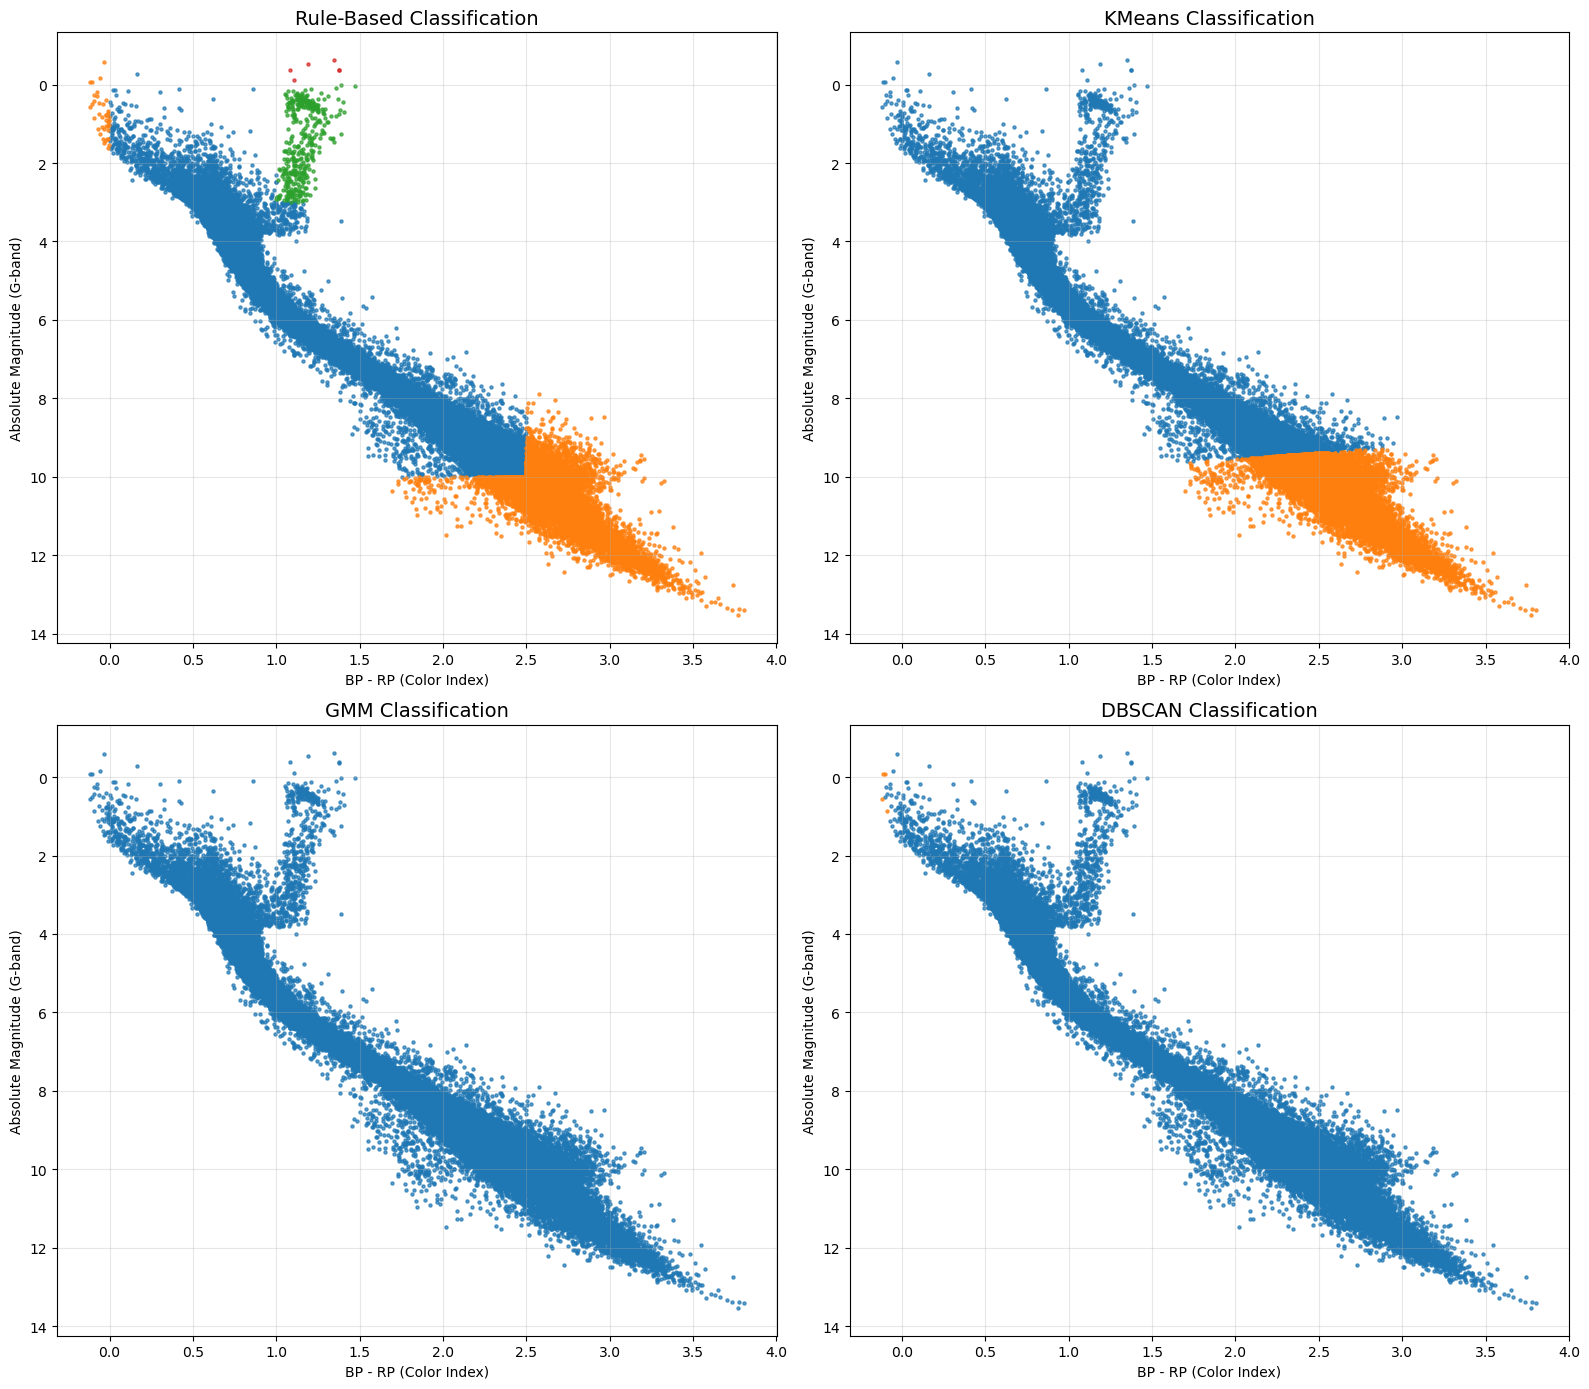

In [16]:
plot_methods = ['phase', 'cluster_phase', 'gmm_cluster_phase', 'dbscan_cluster_phase']
titles = [
    'Rule-Based Classification',
    'KMeans Classification',
    'GMM Classification',
    'DBSCAN Classification'
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, method, title in zip(axes.flatten(), plot_methods, titles):
    for label in comparison[method].unique():
        subset = comparison[comparison[method] == label]
        ax.scatter(
            subset['bp_rp'],
            subset['abs_mag'],
            s=5,
            alpha=0.7,
            label=label
        )
    ax.invert_yaxis()
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('BP - RP (Color Index)')
    ax.set_ylabel('Absolute Magnitude (G-band)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

cluster
4    18040
0    16955
2    13799
1    13556
3     7768
Name: count, dtype: int64
final_phase
4    18040
0    16955
2    13799
1    13556
3     7768
Name: count, dtype: int64


In [36]:
# Mapping from cluster ID to stellar evolutionary phase
phase_mapping = {
    0: 'Main Sequence',
    1: 'Giants',
    2: 'White Dwarfs',
    3: 'Subgiants',
    4: 'Supergiants'
}

# Create a new column with mapped phase names
data['final_phase'] = data['cluster'].map(phase_mapping)
print(data['final_phase'].value_counts())

final_phase
Supergiants      18040
Main Sequence    16955
White Dwarfs     13799
Giants           13556
Subgiants         7768
Name: count, dtype: int64


a statistical analysis of stars in four distinct evolutionary phases — Giants, White Dwarfs, Subgiants, and Supergiants — using two key physical parameters:

- Effective Temperature (`teff_gspphot`) : A measure of the star's surface temperature.
- Absolute Magnitude (G-band) (`abs_mag`) : An indicator of the star's intrinsic brightness (lower values = brighter stars).


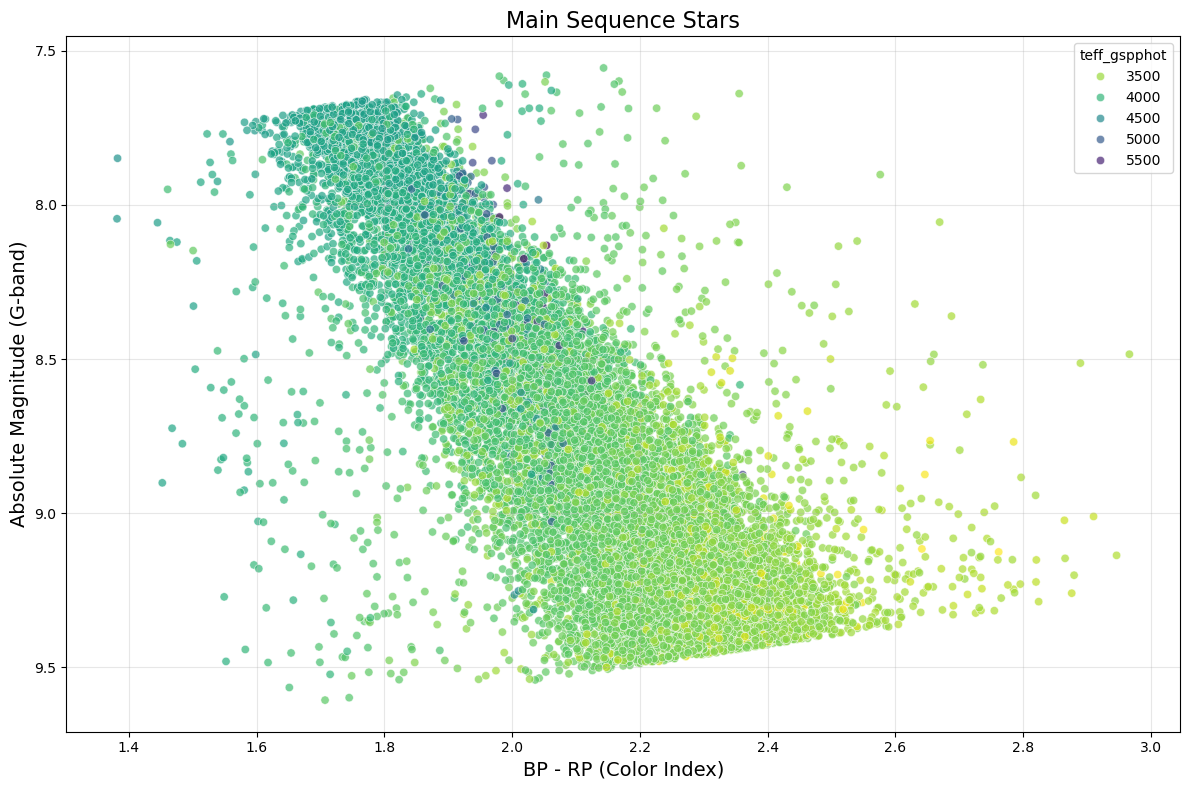


Giant Stars Characteristics (n=13556):
       teff_gspphot       abs_mag
count  13556.000000  13556.000000
mean    5543.917595      5.033659
std      278.738386      0.500421
min     4449.636000      4.082272
25%     5325.464700      4.609168
50%     5581.950650      5.066919
75%     5745.395000      5.463200
max     6322.610400      5.874498

White Dwarf Characteristics (n=13799):
       teff_gspphot       abs_mag
count  13799.000000  13799.000000
mean    4629.520793      6.660768
std      256.133395      0.507152
min     3590.619100      5.829819
25%     4466.535350      6.223755
50%     4600.288600      6.619969
75%     4813.677700      7.052127
max     5680.713400      7.726604

Subgiant Stars Characteristics (n=7768):
       teff_gspphot      abs_mag
count   7768.000000  7768.000000
mean    6301.619254     3.168505
std      833.350542     0.805970
min     4299.928700    -0.624397
25%     5931.307750     2.825738
50%     6188.647000     3.380540
75%     6499.122950     3.761230
ma

In [ ]:
# Phase-Specific Analysis
# Define final phase based on rule-based classification
data['final_phase'] = data['cluster'].map(phase_mapping)  

# Main Sequence Analysis
main_sequence = data[data['final_phase'] == "Main Sequence"]
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='bp_rp', 
    y='abs_mag', 
    hue='teff_gspphot', 
    data=main_sequence, 
    palette='viridis_r',
    alpha=0.7
)
plt.gca().invert_yaxis()
plt.title('Main Sequence Stars', fontsize=16)
plt.xlabel('BP - RP (Color Index)', fontsize=14)
plt.ylabel('Absolute Magnitude (G-band)', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [45]:
# Giant Stars Analysis
giants = data[data['final_phase'] == "Giants"]
print(f"\nGiant Stars Characteristics (n={len(giants)}):")
print(giants[['teff_gspphot', 'abs_mag']].describe())


Giant Stars Characteristics (n=13556):
       teff_gspphot       abs_mag
count  13556.000000  13556.000000
mean    5543.917595      5.033659
std      278.738386      0.500421
min     4449.636000      4.082272
25%     5325.464700      4.609168
50%     5581.950650      5.066919
75%     5745.395000      5.463200
max     6322.610400      5.874498


**Interpretation For Giant stars**
- Giants are relatively cool stars , with temperatures centered around 5500 K , similar to our Sun but larger and more evolved.
- Their luminosities cluster around magnitude 5 , meaning they are moderately bright compared to main-sequence stars.
- These stars have left the main sequence and are now burning hydrogen in a shell around an inert helium core, causing them to expand and cool.

In [46]:
# White Dwarf Analysis
white_dwarfs = data[data['final_phase'] == "White Dwarfs"]
print(f"\nWhite Dwarf Characteristics (n={len(white_dwarfs)}):")
print(white_dwarfs[['teff_gspphot', 'abs_mag']].describe())


White Dwarf Characteristics (n=13799):
       teff_gspphot       abs_mag
count  13799.000000  13799.000000
mean    4629.520793      6.660768
std      256.133395      0.507152
min     3590.619100      5.829819
25%     4466.535350      6.223755
50%     4600.288600      6.619969
75%     4813.677700      7.052127
max     5680.713400      7.726604


**Interpretation**
- White dwarfs are hot but dim objects , which aligns with their nature as remnants of low-mass stars that have shed their outer layers.
- Their high temperatures indicate they are still cooling down after formation, but their low luminosity reflects their small size (Earth-sized).
- The spread in temperatures suggests varying ages among white dwarfs — older ones are cooler.

In [47]:
# Subgiant Analysis
subgiants = data[data['final_phase'] == "Subgiants"]
print(f"\nSubgiant Stars Characteristics (n={len(subgiants)}):")
print(subgiants[['teff_gspphot', 'abs_mag']].describe())


Subgiant Stars Characteristics (n=7768):
       teff_gspphot      abs_mag
count   7768.000000  7768.000000
mean    6301.619254     3.168505
std      833.350542     0.805970
min     4299.928700    -0.624397
25%     5931.307750     2.825738
50%     6188.647000     3.380540
75%     6499.122950     3.761230
max    12333.163000     4.105907


**Interpretation**
- Subgiants are generally hotter and brighter than giants, with many showing higher temperatures due to ongoing core contraction and shell hydrogen burning.
- They are transitioning from the main sequence toward the giant branch , making them a critical phase for understanding stellar evolution.
- The wide range in temperatures and magnitudes indicates a heterogeneous group — some may still be close to the main sequence, while others are closer to becoming full giants.

In [48]:
# Supergiant Analysis
supergiants = data[data['final_phase'] == "Supergiants"]
print(f"\nSupergiant Stars Characteristics (n={len(supergiants)}):")
print(supergiants[['teff_gspphot', 'abs_mag']].describe())


Supergiant Stars Characteristics (n=18040):
       teff_gspphot       abs_mag
count  18040.000000  18040.000000
mean    3407.659152     10.201753
std      199.959244      0.710337
min     2829.354200      9.289991
25%     3213.718175      9.718919
50%     3489.628650      9.968212
75%     3552.714900     10.356490
max     4756.566000     13.539469


**Interpretation**
- Supergiants are massive, luminous stars that have exhausted their core fuel and expanded significantly.
- Their low temperatures suggest many are red supergiants, though there are also blue supergiants at the hotter end of the distribution.
- Their extremely high luminosities (brighter than giants) confirm their status as some of the most massive and evolved stars in the sample.

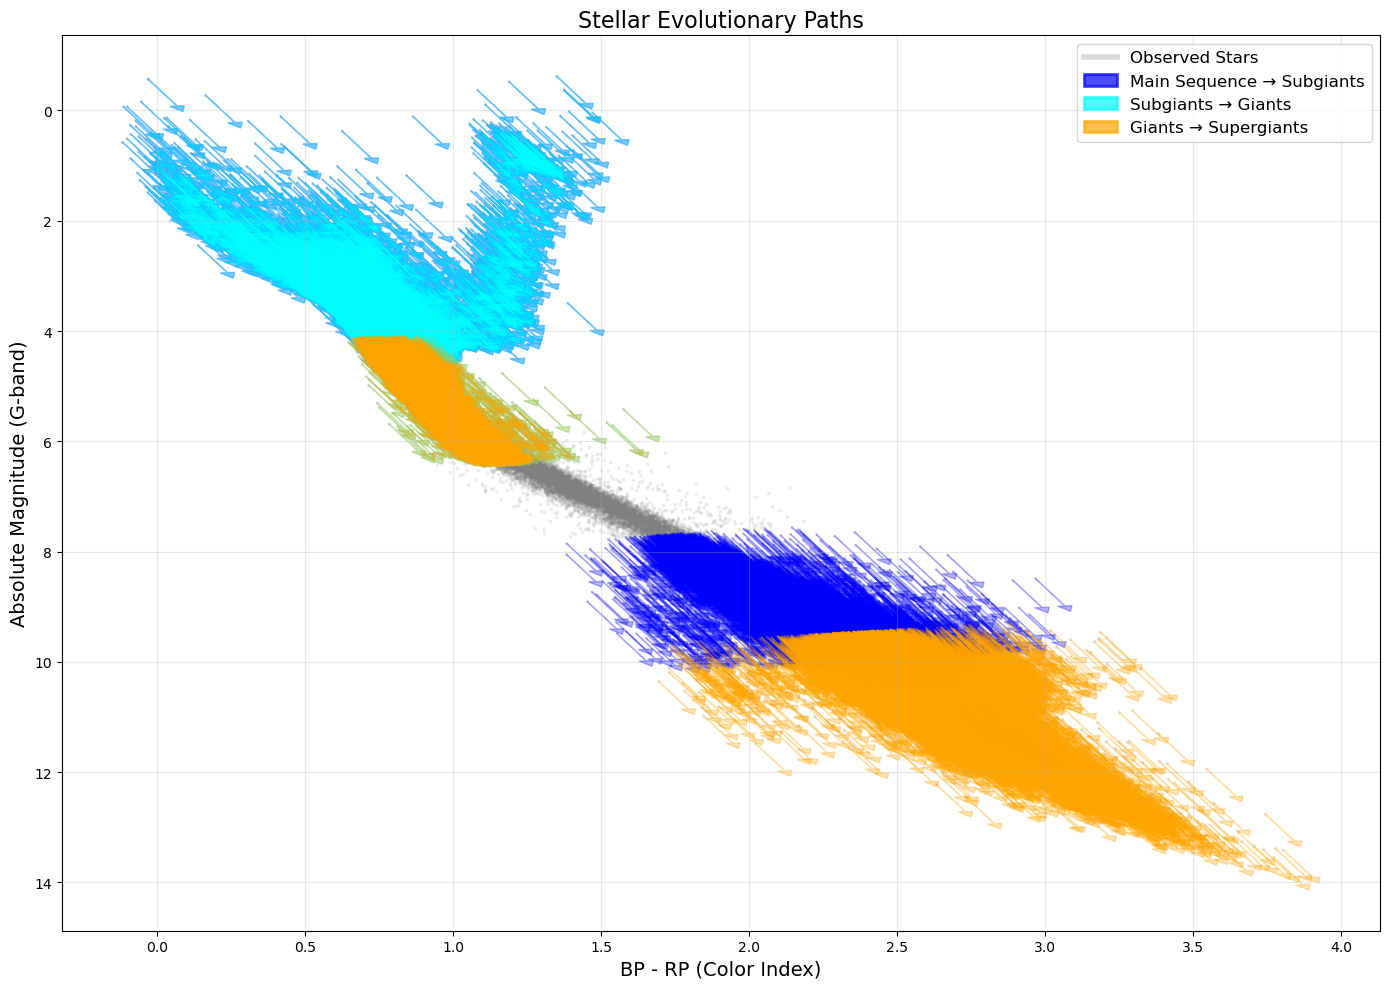

In [44]:
# Evolutionary Path Visualization
phases = ['Main Sequence', 'Subgiants', 'Giants', 'Supergiants']
phase_colors = ['blue', 'cyan', 'orange', 'red']

plt.figure(figsize=(14, 10))

# Plot all stars in background
plt.scatter(
    data['bp_rp'], 
    data['abs_mag'], 
    s=3, 
    alpha=0.1,
    c='gray',
    label='Observed Stars'
)

# Plot evolutionary paths
legend_handles = []
for i in range(len(phases)-1):
    phase_from = phases[i]
    phase_to = phases[i+1]
    
    # Select transition stars
    transition = data[(data['final_phase'] == phase_from) | (data['final_phase'] == phase_to)]
    
    # Plot with arrows
    for _, star in transition.iterrows():
        plt.arrow(
            x=star['bp_rp'], 
            y=star['abs_mag'], 
            dx=0.1,  # Evolutionary direction
            dy=0.5,
            head_width=0.05,
            head_length=0.1,
            fc=phase_colors[i],
            ec=phase_colors[i],
            alpha=0.3
        )

    # Create a proxy arrow for the legend
    legend_arrow = mpatches.FancyArrowPatch(
        (0, 0), (0.3, 0), 
        mutation_scale=20,
        lw=2,
        color=phase_colors[i],
        alpha=0.7,
        label=f'{phase_from} → {phases[i+1]}'
    )
    legend_handles.append(legend_arrow)

# Add static legend items if needed
static_legend = [
    plt.Line2D([0], [0], color='gray', lw=4, alpha=0.3, label='Observed Stars')
]

# Combine legends
plt.legend(handles=static_legend + legend_handles, loc='upper right', fontsize=12)

# Format plot
plt.gca().invert_yaxis()
plt.xlabel('BP - RP (Color Index)', fontsize=14)
plt.ylabel('Absolute Magnitude (G-band)', fontsize=14)
plt.title('Stellar Evolutionary Paths', fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [49]:
output_file = 'gaia_stars_final_classification.csv'
data.to_csv(output_file, index=False)
print(f"Final stellar classification saved to {output_file}")

# Create summary report
summary = data['final_phase'].value_counts().reset_index()
summary.columns = ['Evolutionary Phase', 'Count']
summary['Percentage'] = summary['Count'] / len(data) * 100
print("\nStellar Population Summary:")
display(summary)

Final stellar classification saved to gaia_stars_final_classification.csv

Stellar Population Summary:


,Evolutionary Phase,Count,Percentage
0,Supergiants,18040,25.728058
1,Main Sequence,16955,24.180667
2,White Dwarfs,13799,19.679683
3,Giants,13556,19.333124
4,Subgiants,7768,11.078468


In [1]:
# Mapping from cluster ID to stellar evolutionary phase
phase_mapping = {
    0: 'Main Sequence',
    1: 'Giants',
    2: 'White Dwarfs',
    3: 'Subgiants',
    4: 'Supergiants'
}

# Create a new column with mapped phase names
data['final_phase'] = data['gmm_cluster'].map(phase_mapping)
print(data['final_phase'].value_counts())

NameError: name 'data' is not defined